In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(551) # student ID last 4 digits: 0551 (leading zero omitted, functionally identical)

patients_df = pd.read_csv('/content/drive/MyDrive/dso545/final_dso545/patients.csv')
patients_df.head()
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   patient_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   bmi                         100000 non-null  float64
 4   systolic_bp                 100000 non-null  int64  
 5   diastolic_bp                100000 non-null  int64  
 6   heart_rate                  100000 non-null  int64  
 7   temperature_f               100000 non-null  float64
 8   smoking_status              100000 non-null  object 
 9   alcohol_use                 100000 non-null  object 
 10  exercise_level              100000 non-null  object 
 11  insurance_type              100000 non-null  object 
 12  charlson_index              100000 non-null  int64  
 13  dx_hypertension

##missing values(patients_df)

In [51]:
# check missing values
print(patients_df.isnull().sum())

patient_id                    0
age                           0
gender                        0
bmi                           0
systolic_bp                   0
diastolic_bp                  0
heart_rate                    0
temperature_f                 0
smoking_status                0
alcohol_use                   0
exercise_level                0
insurance_type                0
charlson_index                0
dx_hypertension               0
dx_type2_diabetes             0
dx_hyperlipidemia             0
dx_obesity                    0
dx_coronary_artery_disease    0
dx_heart_failure              0
dx_atrial_fibrillation        0
dx_chronic_kidney_disease     0
dx_copd                       0
dx_asthma                     0
dx_depression                 0
dx_anxiety                    0
dx_hypothyroidism             0
dx_osteoarthritis             0
dx_type1_diabetes             0
dtype: int64


##check outliers(patients_df)


In [52]:
# check outliers
for column in patients_df.select_dtypes(include="number"):
    col = patients_df[column]
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((col < lower) | (col > upper)).sum()
    print(column, "outliers:", count)

age outliers: 0
bmi outliers: 338
systolic_bp outliers: 681
diastolic_bp outliers: 677
heart_rate outliers: 345
temperature_f outliers: 1198
charlson_index outliers: 10
dx_hypertension outliers: 0
dx_type2_diabetes outliers: 15750
dx_hyperlipidemia outliers: 0
dx_obesity outliers: 0
dx_coronary_artery_disease outliers: 9995
dx_heart_failure outliers: 2859
dx_atrial_fibrillation outliers: 2905
dx_chronic_kidney_disease outliers: 21481
dx_copd outliers: 8450
dx_asthma outliers: 11568
dx_depression outliers: 12819
dx_anxiety outliers: 11484
dx_hypothyroidism outliers: 7193
dx_osteoarthritis outliers: 18633
dx_type1_diabetes outliers: 716


In [53]:
# Check actual range of flagged columns(numerical)
cols_to_check = ['temperature_f', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'bmi']
patients_df[cols_to_check].describe()

,temperature_f,systolic_bp,diastolic_bp,heart_rate,bmi
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,98.603557,133.648960,84.391660,72.023400,27.513744
std,0.500259,19.253868,12.472988,11.887678,5.403874
min,96.300000,80.000000,50.000000,45.000000,16.000000
25%,98.300000,121.000000,76.000000,64.000000,23.800000
50%,98.600000,134.000000,84.000000,72.000000,27.500000
75%,98.900000,147.000000,93.000000,80.000000,31.200000
max,100.600000,220.000000,130.000000,124.000000,51.400000


***Outlier Summary***

The IQR method was applied to all numeric columns in the patients dataset.
Binary dx_* columns were excluded from outlier interpretation, as IQR is not
meaningful for binary variables — when the majority of values are 0, any value
of 1 is flagged as an outlier, which is not a true anomaly.

For the remaining numeric columns (vitals and BMI), the actual value ranges were
examined using descriptive statistics. All flagged values fall within clinically
valid ranges. For example, systolic blood pressure ranges from 80 to 220 mmHg,
which is consistent with real-world patient data including hypertensive crises.
Therefore, no outliers were removed from the dataset.

In [54]:
patient_outcome_df = pd.read_csv('/content/drive/MyDrive/dso545/final_dso545/patient_outcome.csv')
# patient_outcome_df.head()
patient_outcome_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             6600 non-null   object 
 1   admission_date         6600 non-null   object 
 2   discharge_date         6600 non-null   object 
 3   length_of_stay_days    6600 non-null   int64  
 4   icu_admission          6600 non-null   int64  
 5   icu_days               6600 non-null   int64  
 6   in_hospital_death      6600 non-null   int64  
 7   discharge_disposition  6600 non-null   object 
 8   readmitted_30d         6600 non-null   int64  
 9   days_to_readmission    944 non-null    float64
 10  primary_drg            6600 non-null   int64  
 11  total_charges_usd      6600 non-null   float64
dtypes: float64(2), int64(6), object(4)
memory usage: 618.9+ KB


## missing values(patient_outcome_df)

In [55]:
# check missing values
print(patient_outcome_df.isnull().sum())

patient_id                  0
admission_date              0
discharge_date              0
length_of_stay_days         0
icu_admission               0
icu_days                    0
in_hospital_death           0
discharge_disposition       0
readmitted_30d              0
days_to_readmission      5656
primary_drg                 0
total_charges_usd           0
dtype: int64


In [56]:
# patient_outcome_df['days_to_readmission'].unique()

In [57]:
patient_outcome_df['readmitted_30d'].value_counts()

,count
readmitted_30d,
0,5656
1,944


***Missing Values***

The only column with missing values is days_to_readmission, with 5,656 NaN entries.
Cross-referencing with the readmitted_30d column confirms that these NaN values
correspond exactly to patients who were not readmitted within 30 days (readmitted_30d = 0).
Therefore, these missing values are not data quality issues — they represent
cases where days_to_readmission is not applicable. The NaN values are retained as-is.

## Defining Outlier(patient_outcome_df)

In [58]:
# ── Outlier Detection ────────────────────────────────────────────────────
for column in patient_outcome_df.select_dtypes(include="number"):
    col = patient_outcome_df[column]
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((col < lower) | (col > upper)).sum()
    print(column, "outliers:", count)

length_of_stay_days outliers: 299
icu_admission outliers: 150
icu_days outliers: 150
in_hospital_death outliers: 79
readmitted_30d outliers: 944
days_to_readmission outliers: 0
primary_drg outliers: 0
total_charges_usd outliers: 441


In [59]:
# patient_outcome_df.info()

In [60]:
# Display unique values for selected columns in patient_outcome_df
columns_to_check_unique = [
    'length_of_stay_days', 'icu_admission', 'icu_days', 'in_hospital_death',
    'readmitted_30d', 'days_to_readmission', 'primary_drg', 'total_charges_usd'
]

print("--- Unique Values Inspection for patient_outcome_df ---")

for col_name in columns_to_check_unique:
    print(f"Unique values for '{col_name}':")
    print(patient_outcome_df[col_name].unique())
    print("-" * 30)


--- Unique Values Inspection for patient_outcome_df ---
Unique values for 'length_of_stay_days':
[19  2  1  6 10  5  4 13 16  3  7 14 11 12  8  9 17 15 18 20 21 30 27 28
 24 22 25 26 23 29]
------------------------------
Unique values for 'icu_admission':
[0 1]
------------------------------
Unique values for 'icu_days':
[0 5 3 4 2 1 6]
------------------------------
Unique values for 'in_hospital_death':
[0 1]
------------------------------
Unique values for 'readmitted_30d':
[0 1]
------------------------------
Unique values for 'days_to_readmission':
[nan 12. 26. 11.  3. 15. 27. 22. 17.  4. 18.  7. 28.  1.  2. 20. 25. 10.
  9. 16.  8.  5. 19. 24.  6. 21. 23. 14. 13. 29.]
------------------------------
Unique values for 'primary_drg':
[194 292 291 470 293 392]
------------------------------
Unique values for 'total_charges_usd':
[10387.91 20523.64  6872.99 ... 28396.83 14161.81 12681.63]
------------------------------


In [61]:
# Check actual range of flagged columns(numerical)
cols_to_check = ['length_of_stay_days', 'icu_days', 'days_to_readmission', 'primary_drg', 'total_charges_usd']
patient_outcome_df[cols_to_check].describe()

,length_of_stay_days,icu_days,days_to_readmission,primary_drg,total_charges_usd
count,6600.000000,6600.000000,944.000000,6600.000000,6600.000000
mean,5.248636,0.081818,14.630297,319.436364,18090.158267
std,4.404447,0.598758,8.308345,82.916607,16934.407781
min,1.000000,0.000000,1.000000,194.000000,2000.000000
25%,2.000000,0.000000,8.000000,291.000000,7767.390000
50%,4.000000,0.000000,15.000000,292.000000,13301.460000
75%,7.000000,0.000000,22.000000,392.000000,22225.085000
max,30.000000,6.000000,29.000000,470.000000,182146.770000


***Outlier Detection — patient_outcome Dataset***

The IQR method was applied to all numeric columns in the patient_outcome dataset.
Binary columns such as icu_admission, in_hospital_death, and readmitted_30d were
excluded from outlier interpretation, as IQR is not meaningful for binary variables.
primary_drg was also excluded as it represents a categorical code rather than a
continuous numeric variable. The remaining flagged columns including
length_of_stay_days, icu_days, and total_charges_usd all show clinically and
operationally reasonable ranges. The maximum total charge of \$182,146 reflects
the reality of high-cost medical cases rather than a data error.

Therefore, no outliers were removed from the patient_outcome dataset.

## Data Featuring

In [62]:
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   patient_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   bmi                         100000 non-null  float64
 4   systolic_bp                 100000 non-null  int64  
 5   diastolic_bp                100000 non-null  int64  
 6   heart_rate                  100000 non-null  int64  
 7   temperature_f               100000 non-null  float64
 8   smoking_status              100000 non-null  object 
 9   alcohol_use                 100000 non-null  object 
 10  exercise_level              100000 non-null  object 
 11  insurance_type              100000 non-null  object 
 12  charlson_index              100000 non-null  int64  
 13  dx_hypertension

In [63]:
# ── Feature Engineering — df_patients ───────────────────────────────────

# Label Encoding — gender
patients_df['gender'] = patients_df['gender'].map({'M': 0, 'F': 1})

# Label Encoding — alcohol_use (ordinal)
patients_df['alcohol_use'] = patients_df['alcohol_use'].map(
    {'none': 0, 'light': 1, 'moderate': 2, 'heavy': 3})

# Label Encoding — exercise_level (ordinal)
patients_df['exercise_level'] = patients_df['exercise_level'].map(
    {'sedentary': 0, 'light': 1, 'moderate': 2, 'vigorous': 3})

# One-Hot Encoding — smoking_status, insurance_type
patients_df = pd.get_dummies(patients_df,
                              columns=['smoking_status', 'insurance_type'],
                              drop_first=False)

In [64]:
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   patient_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  int64  
 3   bmi                         100000 non-null  float64
 4   systolic_bp                 100000 non-null  int64  
 5   diastolic_bp                100000 non-null  int64  
 6   heart_rate                  100000 non-null  int64  
 7   temperature_f               100000 non-null  float64
 8   alcohol_use                 100000 non-null  int64  
 9   exercise_level              100000 non-null  int64  
 10  charlson_index              100000 non-null  int64  
 11  dx_hypertension             100000 non-null  int64  
 12  dx_type2_diabetes           100000 non-null  int64  
 13  dx_hyperlipidem

*Feature Engineering — patients_df*

Several categorical variables in the patients dataset were transformed into
numeric representations to support downstream analysis.

Gender was encoded using label encoding (M=0, F=1) as it contains only two
categories with no ordinal relationship. Alcohol use and exercise level were
also encoded using label encoding, as both variables carry a natural ordinal
ranking — alcohol use ranges from none (0) to heavy (3), and exercise level
ranges from sedentary (0) to vigorous (3). Treating these as ordered numeric
values preserves the meaningful progression between categories.

Smoking status and insurance type were encoded using one-hot encoding, as
neither variable has a natural order. Each category was expanded into its own
binary column, resulting in three new columns for smoking status and five new
columns for insurance type.

In [65]:
# ── Feature Engineering — patient_outcome_df ───────────────────────────────────

patient_outcome_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             6600 non-null   object 
 1   admission_date         6600 non-null   object 
 2   discharge_date         6600 non-null   object 
 3   length_of_stay_days    6600 non-null   int64  
 4   icu_admission          6600 non-null   int64  
 5   icu_days               6600 non-null   int64  
 6   in_hospital_death      6600 non-null   int64  
 7   discharge_disposition  6600 non-null   object 
 8   readmitted_30d         6600 non-null   int64  
 9   days_to_readmission    944 non-null    float64
 10  primary_drg            6600 non-null   int64  
 11  total_charges_usd      6600 non-null   float64
dtypes: float64(2), int64(6), object(4)
memory usage: 618.9+ KB


In [66]:
# One-Hot Encoding — discharge_disposition
patient_outcome_df = pd.get_dummies(patient_outcome_df,
                                     columns=['discharge_disposition'],
                                     drop_first=False)

In [67]:
# Convert date columns to datetime
patient_outcome_df['admission_date'] = pd.to_datetime(patient_outcome_df['admission_date'])
patient_outcome_df['discharge_date'] = pd.to_datetime(patient_outcome_df['discharge_date'])

In [68]:
# Verify length_of_stay_days against calculated difference
patient_outcome_df['calculated_los'] = (
    patient_outcome_df['discharge_date'] - patient_outcome_df['admission_date']
).dt.days

# Check if they match
mismatch = (patient_outcome_df['calculated_los'] != patient_outcome_df['length_of_stay_days']).sum()
print("Mismatches:", mismatch)

Mismatches: 0


In [69]:
# Drop calculated_los as it was only used for verification
patient_outcome_df = patient_outcome_df.drop(columns=['calculated_los'])

In [70]:
# Engineer admission_month and admission_year from admission_date
patient_outcome_df['admission_month'] = patient_outcome_df['admission_date'].dt.month
patient_outcome_df['admission_year'] = patient_outcome_df['admission_date'].dt.year

In [71]:
patient_outcome_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   patient_id                             6600 non-null   object        
 1   admission_date                         6600 non-null   datetime64[ns]
 2   discharge_date                         6600 non-null   datetime64[ns]
 3   length_of_stay_days                    6600 non-null   int64         
 4   icu_admission                          6600 non-null   int64         
 5   icu_days                               6600 non-null   int64         
 6   in_hospital_death                      6600 non-null   int64         
 7   readmitted_30d                         6600 non-null   int64         
 8   days_to_readmission                    944 non-null    float64       
 9   primary_drg                            6600 non-null   int64   

*Feature Engineering — patient_outcome_df*

Admission date and discharge date were converted to datetime format to enable
date-based operations. Two new features, admission_month and admission_year,
were engineered from admission_date to support time-based analysis in
subsequent sections.

The existing length_of_stay_days column was verified by computing the
difference between discharge_date and admission_date. Zero mismatches were
found, confirming the column is accurate. The temporary calculated_los column
used for verification was subsequently dropped.

Discharge disposition was encoded using one-hot encoding, as the six
categories (home, home_health, rehab, hospice, skilled_nursing, expired)
have no natural ordinal ranking. Each category was expanded into its own
binary column, resulting in six new columns.

In [72]:
# patient_outcome_df['discharge_disposition'].unique()
patient_outcome_df.head()

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,readmitted_30d,days_to_readmission,primary_drg,total_charges_usd,discharge_disposition_expired,discharge_disposition_home,discharge_disposition_home_health,discharge_disposition_hospice,discharge_disposition_rehab,discharge_disposition_skilled_nursing,admission_month,admission_year
0,P0063910,2024-03-25,2024-04-13,19,0,0,0,0,NaN,194,10387.91,False,True,False,False,False,False,3,2024
1,P0000550,2021-03-11,2021-03-13,2,0,0,0,0,NaN,292,20523.64,False,False,True,False,False,False,3,2021
2,P0022059,2022-05-30,2022-05-31,1,0,0,0,0,NaN,291,6872.99,False,True,False,False,False,False,5,2022
3,P0092265,2022-04-08,2022-04-14,6,0,0,0,0,NaN,194,20988.84,False,True,False,False,False,False,4,2022
4,P0060646,2019-06-02,2019-06-12,10,0,0,0,1,12.0,470,15913.66,False,False,False,False,True,False,6,2019


## Merging Data

In [73]:
df = patient_outcome_df.merge(patients_df, on='patient_id', how='left')
print(df.shape)

(6600, 52)


In [74]:
# # ── Correlation Matrix ───────────────────────────────────────────────────
# cols_corr = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate',
#              'charlson_index', 'length_of_stay_days', 'total_charges_usd',
#              'readmitted_30d', 'icu_admission', 'in_hospital_death']

# plt.figure(figsize=(12, 8))
# sns.heatmap(df[cols_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
# plt.title('Correlation Matrix — Key Variables')
# plt.tight_layout()
# plt.show()

## A/B Testing 1


*Impact of Insurance Status on Total Charges

In healthcare, insurance status may play a significant role in determining
the total cost of a hospital stay. Insured patients may undergo more
procedures due to coverage, while uninsured patients may delay care until
their condition becomes severe, potentially driving up costs. This test
investigates whether a statistically significant difference in total charges
exists between insured and uninsured patients.


**Hypothesis**
- **Null Hypothesis (H0):** The average total charges for insured and uninsured patients are the same.
- **Alternative Hypothesis (H1):** The average total charges for insured and uninsured patients are different.

**Test**

A two-sided independent samples t-test will be used, as we are comparing
the means of two independent groups without assuming a direction of difference.
Significance level: α = 0.05

In [75]:
# ── A/B Testing — Insurance Status vs Total Charges ─────────────────────
from scipy import stats

# Split into two groups
insured = df[df['insurance_type_uninsured'] == False]['total_charges_usd']
uninsured = df[df['insurance_type_uninsured'] == True]['total_charges_usd']

print('Insured count:', len(insured))
print('Uninsured count:', len(uninsured))
print()
print('Insured mean: $', round(insured.mean(), 2))
print('Uninsured mean: $', round(uninsured.mean(), 2))

Insured count: 5998
Uninsured count: 602

Insured mean: $ 18104.16
Uninsured mean: $ 17950.63


In [76]:
# Two-sided independent samples t-test
statistic, p_value = stats.ttest_ind(insured, uninsured, equal_var=False, alternative='two-sided')

print(f"T-statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Reject H0 — significant difference in total charges")
else:
    print("Result: Fail to reject H0 — no significant difference in total charges")

T-statistic: 0.2093
P-value: 0.8343
Result: Fail to reject H0 — no significant difference in total charges


*Confounding Factor Analysis — ICU Admission*

To investigate whether ICU admission confounds the relationship between
insurance status and total charges, we split the data into two subgroups
and repeat the t-test within each group.

- **H0:** Average total charges for insured and uninsured patients are the same.
- **H1:** Average total charges for insured and uninsured patients are different.
- Significance level: α = 0.05

In [77]:
# ── Confounding Factor — ICU Admission ──────────────────────────────────
icu = df[df['icu_admission'] == 1]
non_icu = df[df['icu_admission'] == 0]

for group_name, group in [('ICU', icu), ('Non-ICU', non_icu)]:
    insured = group[group['insurance_type_uninsured'] == False]['total_charges_usd']
    uninsured = group[group['insurance_type_uninsured'] == True]['total_charges_usd']

    statistic, p_value = stats.ttest_ind(insured, uninsured, equal_var=False, alternative='two-sided')

    print(f"--- {group_name} Group ---")
    print(f"Insured mean: ${insured.mean():.2f}")
    print(f"Uninsured mean: ${uninsured.mean():.2f}")
    print(f"T-statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")
    print()

--- ICU Group ---
Insured mean: $19092.25
Uninsured mean: $14596.85
T-statistic: 1.9927
P-value: 0.0530

--- Non-ICU Group ---
Insured mean: $18081.24
Uninsured mean: $18030.48
T-statistic: 0.0678
P-value: 0.9460



*Results & Interpretation — A/B Testing 1*

**Overall Test**

The two-sided t-test comparing total charges between insured and uninsured
patients showed no statistically significant difference (T = 0.2093, p = 0.8343).
We fail to reject H0.

**Confounding Factor Analysis — ICU Admission**

To examine whether ICU admission confounds this relationship, we repeated
the t-test within ICU and Non-ICU subgroups.

- **Non-ICU patients:** No significant difference in total charges between
  insured and uninsured patients (T = 0.0678, p = 0.9460).
- **ICU patients:** Insured patients incurred higher average charges (\$19,092)
  compared to uninsured patients (\$14,597), with a p-value of 0.0530 —
  marginally above the 0.05 threshold.

**Business Interpretation**


While the overall analysis suggests insurance status does not significantly
impact total charges, the ICU subgroup analysis reveals a borderline finding.
Insured ICU patients tend to incur higher costs, possibly because insurance
coverage enables more aggressive treatment. Healthcare administrators should
be cautious about drawing conclusions from aggregate data alone, as disease
severity may mask important cost differences across patient subgroups.

ICU admission is a potential confounding factor, particularly among the most
critically ill patients.

## A/B Testing 2 — Impact of Gender on 30-Day Readmission Rate

**Business Context**


Gender differences in healthcare outcomes have been widely studied.
This test investigates whether male and female patients have different
30-day readmission rates, which could inform targeted post-discharge
interventions and resource allocation.

**Hypothesis**


- **Null Hypothesis (H0):** The 30-day readmission rate for male and female patients are the same.
- **Alternative Hypothesis (H1):** The 30-day readmission rate for male and female patients are different.

**Test**


A two-sided two-sample proportion z-test will be used, as we are comparing
the readmission rates (proportions) of two independent groups.
Significance level: α = 0.05

In [78]:
# ── A/B Testing 2 — Gender vs 30-Day Readmission Rate ───────────────────
from statsmodels.stats.proportion import proportions_ztest

# Split into two groups (0 = Male, 1 = Female)
male = df[df['gender'] == 0]
female = df[df['gender'] == 1]

# Calculate readmission counts and totals
n_male = len(male)
n_female = len(female)
readmitted_male = male['readmitted_30d'].sum()
readmitted_female = female['readmitted_30d'].sum()

print(f"Male — readmitted: {readmitted_male}, total: {n_male}, rate: {readmitted_male/n_male:.4f}")
print(f"Female — readmitted: {readmitted_female}, total: {n_female}, rate: {readmitted_female/n_female:.4f}")

# Run z-test
successes = np.array([readmitted_male, readmitted_female])
nobs = np.array([n_male, n_female])

stat, p_value = proportions_ztest(successes, nobs, alternative='two-sided')

print(f"\nZ-statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Reject H0 — significant difference in readmission rate")
else:
    print("Result: Fail to reject H0 — no significant difference in readmission rate")

Male — readmitted: 466, total: 3197, rate: 0.1458
Female — readmitted: 478, total: 3403, rate: 0.1405

Z-statistic: 0.6143
P-value: 0.5390
Result: Fail to reject H0 — no significant difference in readmission rate


*Confounding Factor Analysis — COPD (dx_copd)*

COPD is strongly associated with long-term smoking, which historically
has been more prevalent in male patients. Additionally, COPD patients
tend to have poorer respiratory function, potentially leading to higher
readmission rates. We therefore examine whether COPD status confounds
the relationship between gender and 30-day readmission rate.

- **H0:** The 30-day readmission rate for male and female patients are the same.
- **H1:** The 30-day readmission rate for male and female patients are different.
- Significance level: α = 0.05

In [79]:
# ── Confounding Factor Analysis — COPD ──────────────────────────────────
copd = df[df['dx_copd'] == 1]
non_copd = df[df['dx_copd'] == 0]

for group_name, group in [('COPD', copd), ('Non-COPD', non_copd)]:
    male = group[group['gender'] == 0]
    female = group[group['gender'] == 1]

    successes = np.array([male['readmitted_30d'].sum(), female['readmitted_30d'].sum()])
    nobs = np.array([len(male), len(female)])

    stat, p_value = proportions_ztest(successes, nobs, alternative='two-sided')

    print(f"--- {group_name} Group ---")
    print(f"Male rate: {male['readmitted_30d'].mean():.4f}")
    print(f"Female rate: {female['readmitted_30d'].mean():.4f}")
    print(f"Z-statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print()

--- COPD Group ---
Male rate: 0.1667
Female rate: 0.1695
Z-statistic: -0.1124
P-value: 0.9105

--- Non-COPD Group ---
Male rate: 0.1423
Female rate: 0.1365
Z-statistic: 0.6303
P-value: 0.5285



*Confounding Factor Results — COPD (dx_copd)*

Within both the COPD subgroup (Z = -0.1124, p = 0.9105) and the Non-COPD
subgroup (Z = 0.6303, p = 0.5285), no statistically significant difference
in 30-day readmission rates was found between male and female patients.

Therefore, COPD is not a confounding factor in the relationship between
gender and 30-day readmission rate. The overall conclusion remains unchanged —
gender does not significantly influence readmission rates regardless of
COPD status.

In [80]:
df['readmitted_30d'].unique()

array([0, 1])

## Bootstrap 1
Simulation — Bootstrap Analysis of Length of Stay

Length of stay is a key operational metric in hospital management.
It directly affects bed availability, staffing needs, and overall costs.
We use bootstrapping to estimate the variability and uncertainty of the
mean length of stay, and present a 95% confidence interval to support
data-driven operational decision-making.

In [81]:
# ── Bootstrap — Mean Length of Stay ─────────────────────────────────────
n_bootstraps = 5000

bootstrap_means = []

x = df['length_of_stay_days'].to_numpy()
n = len(x)

for _ in range(n_bootstraps):
    bootstrap_sample = np.random.choice(x, size=n, replace=True)
    bootstrap_means.append(bootstrap_sample.mean())

ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)
los_hat = x.mean()

print(f"Observed Mean: {los_hat:.4f} days")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

Observed Mean: 5.2486 days
95% CI: (5.1421, 5.3552)


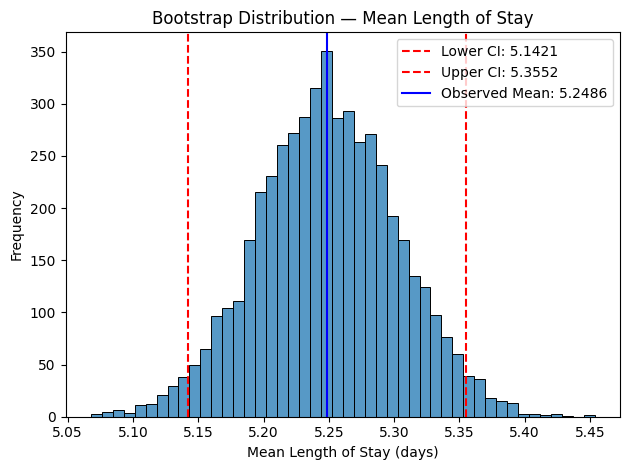

In [82]:
# Plot distribution
sns.histplot(bootstrap_means, edgecolor='black')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'Lower CI: {ci_lower:.4f}')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'Upper CI: {ci_upper:.4f}')
plt.axvline(los_hat, color='blue', linestyle='-', label=f'Observed Mean: {los_hat:.4f}')
plt.title('Bootstrap Distribution — Mean Length of Stay')
plt.xlabel('Mean Length of Stay (days)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Bootstrap Results — Mean Length of Stay**

The observed mean length of stay is 5.25 days.
Based on 5,000 bootstrap samples, the 95% confidence interval is
(5.14, 5.36) days, indicating that the true population mean is
estimated to lie within this narrow range with high confidence.

The tight confidence interval suggests low variability in the estimate,
meaning the sample is sufficiently large to produce a reliable measure
of average hospital stay duration.

--

**Business Interpretation**

**Business Interpretation**

From an operational standpoint, hospital administrators can use this
estimate to plan bed availability and staffing needs. A mean stay of
approximately 5.25 days with a CI of (5.14, 5.36) provides a stable
benchmark for capacity planning. Staffing models built solely around
the point estimate carry residual risk — planning toward the upper
bound of (5.36 days) represents a more conservative scenario that
reduces the likelihood of understaffing or insufficient bed availability
during periods of higher-than-average patient volume. The narrow
interval overall reflects statistical stability, allowing administrators
to allocate resources with greater confidence.

## Bootstrap 2 — 30-Day Readmission Rate

The 30-day readmission rate is a key clinical and financial metric.
Hospitals with high readmission rates may face penalties from CMS
(Centers for Medicare & Medicaid Services). We use bootstrapping
to estimate the uncertainty around the observed readmission rate
and construct a 95% confidence interval.



In [83]:
# ── Bootstrap — 30-Day Readmission Rate ─────────────────────────────────
n_bootstraps = 5000

bootstrap_rates = []

x = df['readmitted_30d'].to_numpy()
n = len(x)

for _ in range(n_bootstraps):
    bootstrap_sample = np.random.choice(x, size=n, replace=True)
    bootstrap_rates.append(bootstrap_sample.mean())

ci_lower = np.percentile(bootstrap_rates, 2.5)
ci_upper = np.percentile(bootstrap_rates, 97.5)
rate_hat = x.mean()

print(f"Observed Readmission Rate: {rate_hat:.4f}")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

Observed Readmission Rate: 0.1430
95% CI: (0.1345, 0.1515)


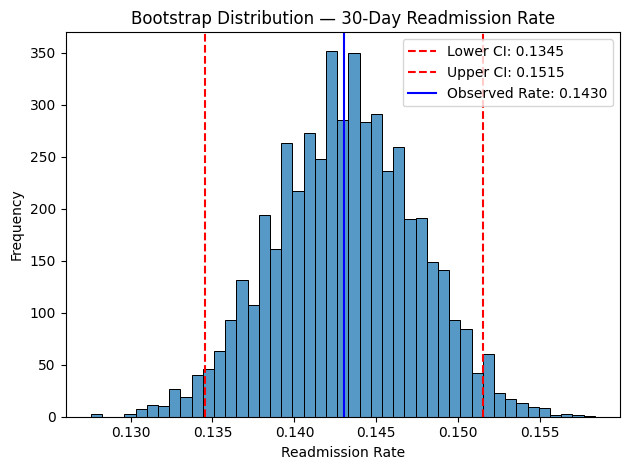

In [84]:
# Plot
sns.histplot(bootstrap_rates, edgecolor='black')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'Lower CI: {ci_lower:.4f}')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'Upper CI: {ci_upper:.4f}')
plt.axvline(rate_hat, color='blue', linestyle='-', label=f'Observed Rate: {rate_hat:.4f}')
plt.title('Bootstrap Distribution — 30-Day Readmission Rate')
plt.xlabel('Readmission Rate')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Bootstrap Results — 30-Day Readmission Rate**

The observed 30-day readmission rate is 14.30%. Based on 5,000 bootstrap
samples, the 95% confidence interval is (13.45%, 15.15%), indicating that
the true population readmission rate is estimated to lie within this range
with high confidence.

The narrow confidence interval reflects the stability of this estimate,
supported by the relatively large sample size of 6,600 patients.

--

**Business Interpretation**

The CMS imposes financial penalties on hospitals with readmission rates
exceeding national benchmarks (approximately 15%). With an observed rate
of 14.30% and an upper CI bound of 15.15%, this hospital is operating
near the penalty threshold. Healthcare administrators should monitor this
metric closely and consider targeted post-discharge interventions to reduce
readmission risk, particularly for high-risk patient segments.

## PCA

In [85]:
df.columns

Index(['patient_id', 'admission_date', 'discharge_date', 'length_of_stay_days',
       'icu_admission', 'icu_days', 'in_hospital_death', 'readmitted_30d',
       'days_to_readmission', 'primary_drg', 'total_charges_usd',
       'discharge_disposition_expired', 'discharge_disposition_home',
       'discharge_disposition_home_health', 'discharge_disposition_hospice',
       'discharge_disposition_rehab', 'discharge_disposition_skilled_nursing',
       'admission_month', 'admission_year', 'age', 'gender', 'bmi',
       'systolic_bp', 'diastolic_bp', 'heart_rate', 'temperature_f',
       'alcohol_use', 'exercise_level', 'charlson_index', 'dx_hypertension',
       'dx_type2_diabetes', 'dx_hyperlipidemia', 'dx_obesity',
       'dx_coronary_artery_disease', 'dx_heart_failure',
       'dx_atrial_fibrillation', 'dx_chronic_kidney_disease', 'dx_copd',
       'dx_asthma', 'dx_depression', 'dx_anxiety', 'dx_hypothyroidism',
       'dx_osteoarthritis', 'dx_type1_diabetes', 'smoking_status_current',

In [86]:
# ── PCA — Select Patient Features ───────────────────────────────────────
metric = ['age', 'gender', 'bmi', 'systolic_bp', 'diastolic_bp',
          'heart_rate', 'temperature_f', 'alcohol_use', 'exercise_level',
          'charlson_index', 'dx_hypertension', 'dx_type2_diabetes',
          'dx_hyperlipidemia', 'dx_obesity', 'dx_coronary_artery_disease',
          'dx_heart_failure', 'dx_atrial_fibrillation',
          'dx_chronic_kidney_disease', 'dx_copd', 'dx_asthma',
          'dx_depression', 'dx_anxiety', 'dx_hypothyroidism',
          'dx_osteoarthritis', 'dx_type1_diabetes',
          'smoking_status_current', 'smoking_status_former',
          'smoking_status_never']

# Check correlation matrix
df[metric].corr()

,age,gender,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,alcohol_use,exercise_level,charlson_index,dx_hypertension,dx_type2_diabetes,dx_hyperlipidemia,dx_obesity,dx_coronary_artery_disease,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes,smoking_status_current,smoking_status_former,smoking_status_never
age,1.000000,-0.005508,0.000961,0.327112,0.245538,0.016047,-0.004521,0.010938,0.006006,0.063574,0.300707,0.035901,0.223843,0.265721,0.059766,0.018402,0.053430,0.019543,0.038530,0.076510,0.097285,0.088686,0.056256,0.106275,0.008207,-0.010614,-0.006027,0.013674
gender,-0.005508,1.000000,0.010618,0.020088,-0.005800,0.005588,0.014128,-0.021729,-0.008991,-0.000736,-0.007284,0.000824,-0.003547,-0.000493,0.012906,0.006288,-0.003246,0.006839,-0.034144,0.003896,-0.016562,-0.005594,0.012521,0.015038,-0.008820,-0.009429,-0.020541,0.025409
bmi,0.000961,0.010618,1.000000,-0.002290,-0.019375,0.006152,-0.009164,0.006246,0.013454,0.016936,0.003423,0.001891,0.004926,0.002777,0.021582,-0.004896,0.008735,0.005332,0.016940,-0.004601,-0.023045,-0.021651,-0.014229,-0.019572,0.004986,-0.020876,0.011248,0.006720
systolic_bp,0.327112,0.020088,-0.002290,1.000000,0.087130,0.008280,0.010945,-0.000101,0.005909,0.022515,0.096498,0.019838,0.065630,0.082805,0.006434,0.030334,0.021173,0.000821,0.025192,0.019725,0.030943,0.027311,0.026775,0.029174,0.001922,-0.011261,0.005823,0.003838
diastolic_bp,0.245538,-0.005800,-0.019375,0.087130,1.000000,0.005004,0.006477,0.003788,0.015683,0.008655,0.070465,-0.011685,0.061421,0.071523,0.022721,0.001181,0.017143,0.006658,0.001444,0.016577,0.029544,0.005864,0.004785,0.013785,-0.001503,-0.019667,0.003896,0.012181
heart_rate,0.016047,0.005588,0.006152,0.008280,0.005004,1.000000,0.005757,-0.012924,-0.026283,0.011507,-0.001174,0.012674,0.007128,-0.008451,0.005454,0.023011,-0.013315,0.002574,0.008680,0.001265,-0.009284,-0.009956,-0.003352,0.016814,-0.014961,0.000030,0.005685,-0.004988
temperature_f,-0.004521,0.014128,-0.009164,0.010945,0.006477,0.005757,1.000000,0.003422,-0.008822,-0.001655,-0.005358,0.003309,0.009259,-0.003235,-0.005040,-0.011234,-0.003340,-0.001977,-0.008385,0.001740,-0.003294,-0.013221,-0.012147,0.023484,0.021740,0.015270,0.012810,-0.023286
alcohol_use,0.010938,-0.021729,0.006246,-0.000101,0.003788,-0.012924,0.003422,1.000000,0.017478,-0.000575,0.004411,-0.027820,-0.006905,-0.011500,-0.004612,-0.000611,-0.001865,0.017363,-0.009553,0.001289,-0.030653,0.007207,0.009782,-0.013679,-0.003661,-0.006249,0.000034,0.004922
exercise_level,0.006006,-0.008991,0.013454,0.005909,0.015683,-0.026283,-0.008822,0.017478,1.000000,0.019659,0.023142,-0.000968,-0.003358,0.011850,-0.003244,0.001147,0.011815,0.018265,0.011289,-0.009639,-0.002781,0.008296,-0.003240,0.010607,0.010828,0.005904,-0.015924,0.009228
charlson_index,0.063574,-0.000736,0.016936,0.022515,0.008655,0.011507,-0.001655,-0.000575,0.019659,1.000000,0.017286,0.321296,0.003457,0.021317,0.269046,0.147375,0.007848,0.793991,0.262839,0.017132,0.027215,-0.006102,0.001085,0.007342,0.181407,0.017479,-0.018915,0.002668


In [87]:
# ── Step 2 — Standardize ─────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

X = df[metric]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [88]:
!pip install factor_analyzer

In [89]:
# ── Step 3 — KMO + Bartlett's Test ──────────────────────────────────────
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# KMO Test
kmo_all_vars, kmo_overall = calculate_kmo(X_scaled)
print(f'KMO overall: {kmo_overall:.4f}')

# Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(X_scaled)
print(f"Bartlett's Test: Chi-square = {chi_square_value:.2f}, p-value = {p_value:.4f}")

KMO overall: 0.5582
Bartlett's Test: Chi-square = 442370.06, p-value = 0.0000


/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [90]:
# ── Step 4 — PCA ─────────────────────────────────────────────────────────
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print('Eigenvalues:')
print(pca.explained_variance_)

print('\nExplained variance ratio:')
print(pca.explained_variance_ratio_)

print('\nCumulative explained variance:')
print(np.cumsum(pca.explained_variance_ratio_))

Eigenvalues:
[1.99940728e+00 1.79229923e+00 1.72748525e+00 1.28880172e+00
 1.10424886e+00 1.08486084e+00 1.05518156e+00 1.05006208e+00
 1.04170628e+00 1.02400376e+00 1.02221029e+00 1.01467125e+00
 9.97985931e-01 9.96478553e-01 9.89915764e-01 9.79804385e-01
 9.65969627e-01 9.63113067e-01 9.56701866e-01 9.40660040e-01
 9.24015015e-01 9.19515779e-01 9.00811448e-01 8.89868429e-01
 8.76053598e-01 4.98411181e-01 1.74546269e-15 9.58870564e-16]

Explained variance ratio:
[7.13965837e-02 6.40009882e-02 6.16865538e-02 4.60216588e-02
 3.94314839e-02 3.87391595e-02 3.76793457e-02 3.74965350e-02
 3.71981587e-02 3.65660216e-02 3.65019789e-02 3.62327681e-02
 3.56369543e-02 3.55831276e-02 3.53487777e-02 3.49877118e-02
 3.44936881e-02 3.43916836e-02 3.41627468e-02 3.35899113e-02
 3.29955362e-02 3.28348735e-02 3.21669629e-02 3.17762000e-02
 3.12828879e-02 1.77977023e-02 6.23285082e-17 3.42401886e-17]

Cumulative explained variance:
[0.07139658 0.13539757 0.19708413 0.24310578 0.28253727 0.32127643
 0.35

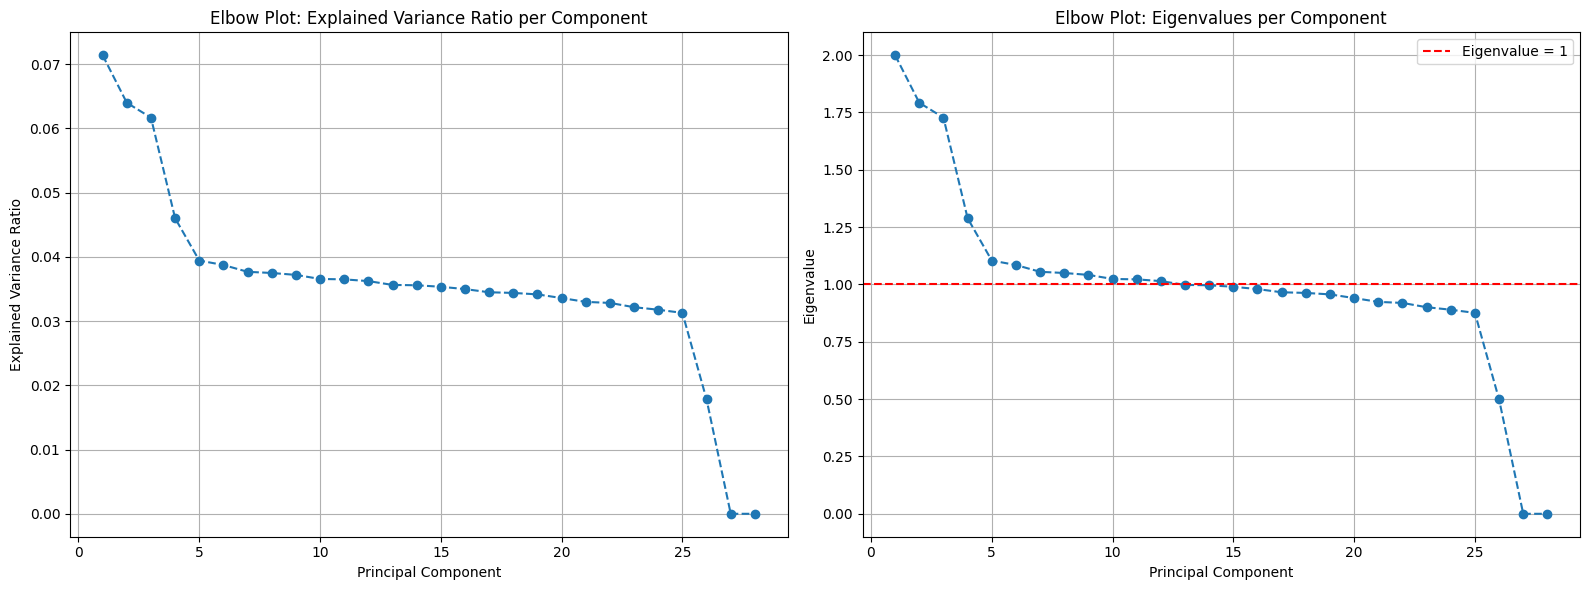

In [91]:
# ── Step 5 — Scree Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Explained Variance Ratio
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1),
             pca.explained_variance_ratio_, marker='o', linestyle='--')
axes[0].set_title('Elbow Plot: Explained Variance Ratio per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(True)

# Eigenvalues
axes[1].plot(range(1, len(pca.explained_variance_) + 1),
             pca.explained_variance_, marker='o', linestyle='--')
axes[1].axhline(y=1, color='red', linestyle='--', label='Eigenvalue = 1')
axes[1].set_title('Elbow Plot: Eigenvalues per Component')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Eigenvalue')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [92]:
# ── Step 6 — Select 5 PCs and build new dataframe ───────────────────────
# Keep first 5 principal components
pca_components = pd.DataFrame(X_pca[:, :5], columns=['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5'])

# Get non-metric columns to keep
non_metric_columns = df.drop(columns=metric).reset_index(drop=True)

# Combine with PCA components
df_pca = pd.concat([non_metric_columns, pca_components], axis=1)

print(df_pca.shape)
print(df_pca.head())

(6600, 29)
  patient_id admission_date discharge_date  length_of_stay_days  \
0   P0063910     2024-03-25     2024-04-13                   19   
1   P0000550     2021-03-11     2021-03-13                    2   
2   P0022059     2022-05-30     2022-05-31                    1   
3   P0092265     2022-04-08     2022-04-14                    6   
4   P0060646     2019-06-02     2019-06-12                   10   

   icu_admission  icu_days  in_hospital_death  readmitted_30d  \
0              0         0                  0               0   
1              0         0                  0               0   
2              0         0                  0               0   
3              0         0                  0               0   
4              0         0                  0               1   

   days_to_readmission  primary_drg  total_charges_usd  \
0                  NaN          194           10387.91   
1                  NaN          292           20523.64   
2                  Na

In [93]:
# ── Step 7 — PC Loadings Interpretation ─────────────────────────────────
loadings = pd.DataFrame(
    pca.components_[:5].T,
    index=metric,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)

# Show top 5 contributors per PC
for pc in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']:
    print(f"\n--- {pc} Top Contributors ---")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))


--- PC1 Top Contributors ---
charlson_index               0.601596
dx_chronic_kidney_disease    0.469607
age                          0.345908
systolic_bp                  0.204852
dx_type2_diabetes            0.199394
Name: PC1, dtype: float64

--- PC2 Top Contributors ---
age                          0.492275
charlson_index               0.388819
dx_chronic_kidney_disease    0.357338
systolic_bp                  0.318749
dx_hypertension              0.302529
Name: PC2, dtype: float64

--- PC3 Top Contributors ---
smoking_status_never      0.751560
smoking_status_former     0.537367
smoking_status_current    0.356251
dx_obesity                0.071308
age                       0.059470
Name: PC3, dtype: float64

--- PC4 Top Contributors ---
smoking_status_current    0.757307
smoking_status_former     0.608765
dx_hypothyroidism         0.125594
bmi                       0.086772
dx_depression             0.079921
Name: PC4, dtype: float64

--- PC5 Top Contributors ---
dx_type2_diabete

*PCA — Results and Component Selection*

PCA was applied to 28 patient-level features including demographics,
vital signs, lifestyle factors, and binary diagnostic flags (dx_*).
All features were standardized prior to PCA using StandardScaler.

Based on Kaiser's Criterion, 12 components have eigenvalues greater
than 1. However, given that the majority of input variables are binary
diagnostic flags — which naturally distribute variance across many
components — we prioritize clustering interpretability over cumulative
variance explained. Therefore, 5 principal components were retained,
explaining approximately 28.3% of the total variance.

*PCA — Principal Component Interpretation*

The top contributing variables for each retained component were examined
using absolute loadings. Each component was interpreted as follows:

- **PC1 — Chronic Disease Burden:** Dominated by charlson_index,
  dx_chronic_kidney_disease, and age. This component captures patients
  with high comorbidity load and advanced disease severity.

- **PC2 — Age-Related Cardiovascular Risk:** Driven by age, systolic_bp,
  and dx_hypertension, alongside charlson_index. This component reflects
  the compounding effect of aging on cardiovascular health, distinct from
  PC1 in its emphasis on blood pressure and hypertension.

- **PC3 — Smoking History:** Primarily loaded by smoking_status_never and
  smoking_status_former. This component separates patients who have never
  smoked or have quit from active smokers, capturing long-term smoking
  exposure patterns.

- **PC4 — Active Smoking Behavior:** Driven by smoking_status_current and
  smoking_status_former. While related to PC3, this component more
  specifically captures current and recent smoking behavior. The separation
  of PC3 and PC4 is expected given the one-hot encoded smoking variables —
  PCA decomposes their inter-correlation into two distinct dimensions.

- **PC5 — Lifestyle & Metabolic Risk:** Loaded by dx_type2_diabetes,
  alcohol_use, exercise_level, and dx_osteoarthritis. This component
  reflects lifestyle-driven metabolic risk factors, grouping patients
  whose conditions are associated with diet, physical activity, and
  substance use patterns.

These five components provide a clinically interpretable foundation for
downstream patient segmentation via clustering.

## Clustering

Patient demographic, vital sign, lifestyle, and diagnostic variables were selected as clustering inputs, as these represent pre-existing patient characteristics independent of the hospitalization outcome. Outcome variables such as readmitted_30d and total_charges_usd were intentionally excluded to ensure that clusters reflect patient profiles rather than post-admission results, preserving the validity of downstream outcome comparisons across clusters.



In [94]:
# ── Clustering — Prepare Data ────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Use 5 PCA components for clustering
df_kmeans = df_pca[['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5']].copy()

# Scale the PCA components
scaler_kmeans = StandardScaler()
X_kmeans_scaled = scaler_kmeans.fit_transform(df_kmeans)

# Test k from 3 to 10
k_range = range(3, 11)
random_seed = 551

print('K-Means Clustering — Silhouette Scores')
print('--------------------------------------------------')

results = []
kmeans_models = {}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=random_seed, n_init=100)
    kmeans.fit(X_kmeans_scaled)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_kmeans_scaled, labels)
    print(f"k={k}, silhouette score: {silhouette_avg:.4f}")
    results.append({'k': k, 'silhouette_score': silhouette_avg})
    kmeans_models[k] = kmeans

K-Means Clustering — Silhouette Scores
--------------------------------------------------
k=3, silhouette score: 0.3318
k=4, silhouette score: 0.2826
k=5, silhouette score: 0.2704
k=6, silhouette score: 0.2628
k=7, silhouette score: 0.2718
k=8, silhouette score: 0.2696
k=9, silhouette score: 0.2584
k=10, silhouette score: 0.2586


In [95]:
# ── Clustering — Apply k=3 ──────────────────────────────────────────────
k3 = KMeans(n_clusters=3, random_state=random_seed, n_init=100)
k3.fit(X_kmeans_scaled)
labels = k3.labels_

df_pca['cluster'] = labels

print(df_pca['cluster'].value_counts())

cluster
1    3676
0    1659
2    1265
Name: count, dtype: int64


In [96]:
# ── Cluster Analysis — Key Outcomes ─────────────────────────────────────
# Merge cluster labels back to original df
df['cluster'] = labels

# Analyze key outcomes by cluster
outcome_cols = ['readmitted_30d', 'total_charges_usd',
                'length_of_stay_days', 'icu_admission',
                'in_hospital_death', 'charlson_index',
                'age', 'dx_heart_failure',
                'dx_chronic_kidney_disease']

pd.set_option('display.max_columns', None)
df.groupby('cluster')[outcome_cols].mean().round(4)

,readmitted_30d,total_charges_usd,length_of_stay_days,icu_admission,in_hospital_death,charlson_index,age,dx_heart_failure,dx_chronic_kidney_disease
cluster,,,,,,,,,
0,0.1368,18592.3531,5.3056,0.0229,0.0115,1.3098,77.2206,0.0392,0.3755
1,0.1425,18133.5002,5.2070,0.0229,0.0136,1.3507,77.5672,0.0375,0.3836
2,0.1526,17305.6001,5.2949,0.0221,0.0079,1.3897,77.0458,0.0419,0.3953


*Clustering — K-Means Patient Segmentation*

**Method:** K-Means clustering was applied using the 5 principal components derived from PCA as input features. The data was standardized prior to clustering. We tested k from 3 to 10 and selected the optimal k based on the highest average silhouette score.

**Selecting Optimal k:** k=3 yielded the highest silhouette score of 0.3318, indicating the most distinct cluster structure. While this falls in the weak-to-moderate range (0.26–0.50), it reflects meaningful segmentation given the high proportion of binary diagnostic variables in the dataset.

**Cluster Profiles:**
| Cluster | Size | Readmission Rate | Avg Charges | Avg LOS | Charlson Index |
|---------|------|-----------------|-------------|---------|----------------|
| 0 | 1,659 | 13.68% | \$18,592 | 5.31 days | 1.31 |
| 1 | 3,676 | 14.25% | \$18,134 | 5.21 days | 1.35 |
| 2 | 1,265 | 15.26% | \$17,306 | 5.29 days | 1.39 |

**Cluster 2 — High Risk Group:** Highest readmission rate (15.26%) and highest Charlson Index (1.39), suggesting patients with greater comorbidity burden. Despite higher clinical risk, this group has the lowest average charges (\$17,306), potentially indicating more conservative treatment. This group warrants targeted post-discharge interventions to reduce readmission risk.

**Cluster 0 — High Cost Group:** Lowest readmission rate (13.68%) but highest average charges (\$18,592) and longest length of stay (5.31 days), suggesting patients who receive more intensive treatment during admission.

**Cluster 1 — Moderate Group:** The largest group (55.7% of patients) with metrics falling between the other two clusters, representing the average patient profile.

**Business Implications:** While cluster differences are modest — partly due to the binary nature of diagnostic variables limiting PCA separation — the segmentation still provides actionable insights. Cluster 2 represents a high-risk population that could benefit from enhanced discharge planning and follow-up care. Targeting interventions toward this group could help reduce the hospital's overall readmission rate and avoid CMS penalties.

##Overall Business & Healthcare Implications

**What are the operational or financial implications of reducing readmissions?**


Cluster 2 contains 1,265 high-risk patients with a readmission rate of 15.26%.
Even a modest 2% reduction in this group's readmission rate would prevent
approximately 25 readmissions. Given an average index admission cost of \$17,306,
this translates to potential savings of over \$430,000. Furthermore, since
total_charges_usd represents index admission costs only and does not include
readmission costs, the true financial burden of Cluster 2 is likely higher
than reflected in this analysis. Reducing readmissions in this group would
also help the hospital avoid CMS financial penalties.

**How reliable are the insights given the variability captured through simulation?**


Bootstrap analysis confirmed that the observed overall readmission rate of
14.30% has a 95% confidence interval of (13.45%, 15.15%), indicating a
reliable and stable estimate. The narrow CI — spanning less than 2% —
reflects the statistical stability of this metric given the sample size
of 6,600 patients. This provides confidence that the cluster-level
readmission findings, particularly Cluster 2's elevated rate of 15.26%,
are not driven by sampling variability but reflect genuine differences
in patient risk profiles.